### Sobre o notebook

Esse notebook contém diversos desafios envolvendo os aprendizados de cada aula. É um notebook construído com o enunciado de cada desafio e com espaço para construir e executar suas soluções. Se for necessário adicionar mais células de código para solucionar o desafio, fique à vontade para acrescentar.

# Aula 1

### Desafio 1

Faça a leitura da base de dados de diabetes e realize a divisão dos dados em variáveis explicativas e variável alvo (x e y).

In [1]:
import pandas as pd

In [2]:
dados = pd.read_csv("Dados/diabetes.csv")

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [4]:
dados.head()

,glicemia,pressao_sanguinea,dobra_cutane_triceps,insulina,imc,diabetes
0,66,23,94,28.1,0.167,0
1,40,35,168,43.1,2.288,1
2,50,32,88,31.0,0.248,1
3,70,45,543,30.5,0.158,1
4,60,23,846,30.1,0.398,1


In [5]:
X = dados.drop("diabetes", axis=1)
y = dados.diabetes

### Desafio 2

Realize a divisão dos dados entre treino e teste.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=4)

### Desafio 3

Crie 2 modelos utilizando os algoritmos [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) e [RandomForestClassifer](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) e avalie a acurácia de treino e teste, escolhendo valores para o parâmetro `max_depth` para os modelos não se especializarem demais no padrão dos dados de treino.

In [18]:
modelo_arvore = DecisionTreeClassifier(max_depth=7)
modelo_random = RandomForestClassifier(max_depth=7)

In [19]:
modelo_arvore.fit(X_train, y_train)
modelo_random.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
print(f"Acuracia modelo Arvore: {modelo_arvore.score(X_test, y_test)}")
print(f"Acuracia modelo Random Forest: {modelo_random.score(X_test, y_test)}")


Acuracia modelo Arvore: 0.6565656565656566
Acuracia modelo Random Forest: 0.696969696969697


### Desafio 4

Construa uma matriz de confusão para cada um dos modelos para avaliar o desempenho das previsões.

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [22]:
y_predict_arvore = modelo_arvore.predict(X_test)
y_predict_random = modelo_random.predict(X_test)

In [24]:
matriz_conf_arvore = confusion_matrix(y_test, y_predict_arvore)
matriz_conf_random = confusion_matrix(y_test, y_predict_random)

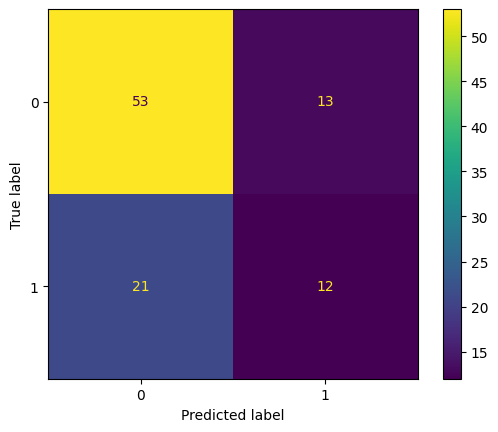

In [25]:
visualicao = ConfusionMatrixDisplay(confusion_matrix=matriz_conf_arvore)
visualicao.plot();

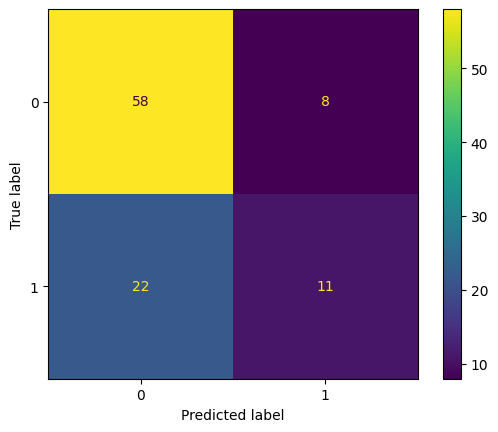

In [26]:
visualicao = ConfusionMatrixDisplay(matriz_conf_random)
visualicao.plot();

# Aula 2

### Desafio 1

Extraia as métricas acurácia, recall, precisão e F1-Score dos modelos de classificação gerados no desafio da aula 1.

In [27]:
from sklearn.metrics import recall_score, precision_score, f1_score,  accuracy_score

In [28]:
print(f"Acuracia modelo Arvore: {accuracy_score(y_test, y_predict_arvore)}")
print(f"Acuracia modelo Random Forest: {accuracy_score(y_test, y_predict_random)}")

Acuracia modelo Arvore: 0.6565656565656566
Acuracia modelo Random Forest: 0.696969696969697


In [29]:
print(f"Recall modelo Arvore: {recall_score(y_test, y_predict_arvore)}")
print(f"Recall modelo Random Forest: {recall_score(y_test, y_predict_random)}")

Recall modelo Arvore: 0.36363636363636365
Recall modelo Random Forest: 0.3333333333333333


In [30]:
print(f"Precisão modelo Arvore: {precision_score(y_test, y_predict_arvore)}")
print(f"Precisão modelo Random Forest: {precision_score(y_test, y_predict_random)}")

Precisão modelo Arvore: 0.48
Precisão modelo Random Forest: 0.5789473684210527


In [31]:
print(f"f1_score modelo Arvore: {f1_score(y_test, y_predict_arvore)}")
print(f"f1_score modelo Random Forest: {f1_score(y_test, y_predict_random)}")

f1_score modelo Arvore: 0.41379310344827586
f1_score modelo Random Forest: 0.4230769230769231


### Desafio 2

Obtenha a curva ROC e a métrica AUC dos modelos de classificação gerados no desafio da aula 1, comparando as curvas no mesmo gráfico.

*Como uma dica, vasculhe a documentação do `Scikit-learn` a partir deste [link](https://scikit-learn.org/stable/auto_examples/release_highlights/plot_release_highlights_0_22_0.html#new-plotting-api) e verifique uma forma de apresentar os resultados das curvas no mesmo gráfico usando o matplotlib*

In [33]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score
import matplotlib.pyplot as plt

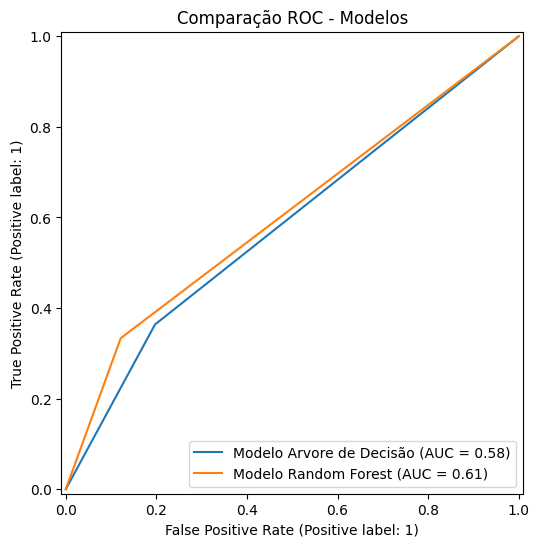

In [38]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, y_predict_arvore, name="Modelo Arvore de Decisão", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_predict_random, name="Modelo Random Forest", ax=ax)
plt.title("Comparação ROC - Modelos")
plt.show()


### Desafio 3

Obtenha a curva precisão x recall e a métrica AP dos modelos de classificação gerados no desafio da aula 1, comparando as curvas no mesmo gráfico.

*Como uma dica, vasculhe a documentação do `Scikit-learn` a partir deste [link](https://scikit-learn.org/stable/auto_examples/release_highlights/plot_release_highlights_0_22_0.html#new-plotting-api) e verifique uma forma de apresentar os resultados das curvas no mesmo gráfico usando o matplotlib*

In [35]:
from sklearn.metrics import PrecisionRecallDisplay

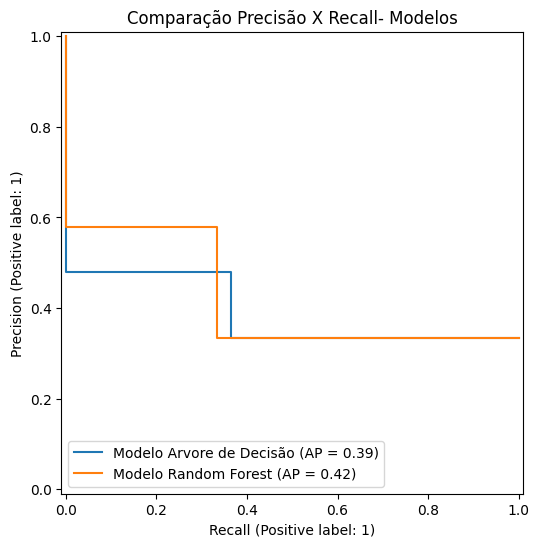

In [37]:
fig, ax = plt.subplots(figsize=(6, 6))
PrecisionRecallDisplay.from_predictions(y_test, y_predict_arvore, name="Modelo Arvore de Decisão", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_predict_random, name="Modelo Random Forest", ax=ax)
plt.title("Comparação Precisão X Recall- Modelos")
plt.show()


### Desafio 4

Gere os relatórios de métricas dos modelos de classificação gerados no desafio da aula 1.

In [39]:
from sklearn.metrics import classification_report

In [42]:
print(f"Relatório Modelo Arvore de decisão \n{classification_report(y_test, y_predict_arvore)}")

Relatório Modelo Arvore de decisão 
              precision    recall  f1-score   support

           0       0.72      0.80      0.76        66
           1       0.48      0.36      0.41        33

    accuracy                           0.66        99
   macro avg       0.60      0.58      0.59        99
weighted avg       0.64      0.66      0.64        99



In [43]:
print(f"Relatório Modelo Random Forest \n{classification_report(y_test, y_predict_random)}")

Relatório Modelo Random Forest 
              precision    recall  f1-score   support

           0       0.72      0.88      0.79        66
           1       0.58      0.33      0.42        33

    accuracy                           0.70        99
   macro avg       0.65      0.61      0.61        99
weighted avg       0.68      0.70      0.67        99



# Aula 3

### Desafio 1

Crie uma função para calcular o intervalo de confiança dos resultados de uma validação cruzada com 2 desvios padrão. A função precisa ter um parâmetro para receber uma lista com os desempenhos da validação cruzada e outro para apresentar o nome do modelo utilizado na validação cruzada. Exemplo de retorno da função:

> Intervalo de confiança ("nome do modelo"): ["valor mínimo do intervalo", "valor máximo do intervalo"]



In [56]:
def intervalo_conf(resultados, nome):
    media = resultados.mean()
    desvio = resultados.std()
    print(f"O intervalo de confiança ({nome}): [{media - 2 * desvio}, {min(media + 2 * desvio, 1)}]")

### Desafio 2

Avalie o desempenho dos modelos com um intervalo de confiança utilizando a validação cruzada com o método [`KFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html), usando 10 partes e embaralhando os dados antes da separação. Use o método [`cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) que não retorna o tempo de execução, apenas as métricas.

In [46]:
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold, cross_val_score

In [57]:
kf = KFold(n_splits=10, shuffle=True, random_state=4)
resultado_arvore = cross_val_score(modelo_arvore, X, y, cv=kf)
resultado_random = cross_val_score(modelo_random, X, y, cv=kf)
intervalo_conf(resultado_arvore, "Arvore de Decisão")
intervalo_conf(resultado_random, "Random Forest")

O intervalo de confiança (Arvore de Decisão): [0.5493943334530185, 0.8056056665469815]
O intervalo de confiança (Random Forest): [0.5805720573842361, 0.7891715323593538]


### Desafio 3

Avalie o desempenho dos modelos com um intervalo de confiança utilizando a validação cruzada (`cross_val_score`) com o método [`StratifiedKFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html#sklearn.model_selection.StratifiedKFold), usando 10 partes e embaralhando os dados antes da separação e avaliando a métrica F1-Score.

In [61]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=4)
resultado_arvore = cross_val_score(modelo_arvore, X, y, cv=skf, scoring="f1")
resultado_random = cross_val_score(modelo_random, X, y, cv=skf, scoring="f1")
intervalo_conf(resultado_arvore, "Arvore de Decisão")
intervalo_conf(resultado_random, "Random Forest")

O intervalo de confiança (Arvore de Decisão): [0.1770391041239231, 0.7822998178236945]
O intervalo de confiança (Random Forest): [0.26754330167621687, 0.6950689376586611]


### Desafio 4

Avalie o desempenho dos modelos utilizando a validação cruzada (`cross_val_score`) com o método [`LeaveOneOut`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.LeaveOneOut.html).

O método LeaveOneOut vai gerar um modelo para cada uma das linhas da base de dados, portanto a lista de resultados terá taxa de acerto apenas de 0 ou 1 para cada modelo. Dessa forma, extraia apenas a média do resultado, sem utilizar o intervalo de confiança.


In [62]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()

resultado_arvore = cross_val_score(modelo_arvore, X, y, cv = loo)
resultado_random = cross_val_score(modelo_random, X, y, cv = loo)

print(f"Acurácia média (Arvore de Decisão): {resultado_arvore.mean()}")
print(f"Acurácia média (Random Forest):{resultado_random.mean()}") 


Acurácia média (Arvore de Decisão): 0.5786802030456852
Acurácia média (Random Forest):0.6776649746192893


# Aula 4

### Desafio 1

Verifique a proporção de dados da variável alvo do conjunto de dados de diabetes. Essa análise pode ser feita a partir da porcentagem de dados ou com a utilização de um gráfico de contagem para entender se há um desbalanceamento de dados.

### Desafio 2

Utilize um [`pipeline`](https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.Pipeline.html) contendo ajuste do modelo e o balanceamento dos dados usando o oversampling com [`SMOTE`](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html), obtendo a média do F1-Score de uma validação cruzada com `StratifiedKFold`.

### Desafio 3

 Utilize um [`pipeline`](https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.Pipeline.html) contendo ajuste do modelo e o balanceamento dos dados usando o undersampling com [`Nearmiss`](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html) na sua versão 3, obtendo a média do F1-Score de uma validação cruzada com `StratifiedKFold`.

### Desafio 4

Escolha o modelo que obteve o melhor desempenho ao comparar as estratégias de oversampling e undersampling e realize o teste do modelo nos dados de teste que foram separados no início dos desafios.